# MediCore NL2SQL Platform — Exploration Notebook

This notebook walks through every layer of the system interactively.
Each section explains **why** a particular framework or design choice was made,
then provides runnable code to test it live.

---

## Sections

| # | Section | API Key? |
|---|---------|----------|
| 0 | Setup & Framework Rationale | No |
| 1 | Database Loading | No |
| 2 | params.yaml Config | No |
| 3 | LangChain SQLDatabase (Schema) | No |
| 4 | Loguru Logger | No |
| 5 | Validator Agent (3-layer safety) | No |
| 6 | SQL Executor | No |
| 7 | Intent Router | **Yes** |
| 8 | SQL Generator | **Yes** |
| 9 | Result Interpreter | **Yes** |
| 10 | Full LangGraph Pipeline | **Yes** |
| 11 | LangFuse Traces | Optional |
| 12 | Unit Tests | No |

---
## Section 0 — Setup & Framework Rationale

### Why these frameworks?

| Framework | Why |
|-----------|-----|
| **OpenRouter + GPT-4o** | Single API key for 200+ models. OpenAI-compatible endpoint — swap to Claude or Gemini by changing one line in `params.yaml`. |
| **LangGraph** | Proper typed state machine. Retry edges, conditional routing, and fallback paths are *first-class graph constructs* — not nested if/else blocks in a for-loop. |
| **LangChain (LCEL)** | `prompt | llm | parser` pipe syntax makes data flow explicit. Built-in retry/backoff via `.with_retry()`. `JsonOutputParser` handles parse failures gracefully. |
| **LangChain SQLDatabase** | Wraps SQLAlchemy → works with SQLite, PostgreSQL, MySQL without code changes. `get_table_info()` returns schema + sample rows for the LLM prompt. |
| **SQLite** | Zero installation, file-based. The same `SQLDatabase` code works with PostgreSQL in prod (change `DB_PATH` in `.env`). |
| **Loguru** | `from utils.log import logger` — done. No `getLogger(__name__)` boilerplate. Colourised console + rotating file output configured in `params.yaml`. |
| **LangFuse** | Open-source LLM observability. Traces every agent call with latency + tokens. Works without an account (local JSON fallback). |
| **Streamlit** | Python-native UI — no HTML/CSS/JS. `st.cache_resource` compiles the LangGraph pipeline once across all sessions. |

In [1]:
# ── Add project root to Python path (run this first) ─────────────────────────
import sys, os
# Go up one level from notebook/ to project root
project_root = os.path.dirname(os.path.abspath('.'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Alternative if the above doesn't work:
# sys.path.insert(0, r'd:/Zuu crew/medicore_nl2sql')

os.chdir(project_root)  # Set working dir to project root
print(f'Working directory: {os.getcwd()}')

Working directory: d:\Zuu crew\medicore_nl2sql


In [2]:
# ── Check all packages are installed ─────────────────────────────────────────
packages = [
    'langchain', 'langchain_openai', 'langchain_community',
    'langgraph', 'loguru', 'sqlparse', 'sqlalchemy',
    'dotenv', 'yaml', 'streamlit', 'plotly', 'pandas',
]

missing = []
for pkg in packages:
    try:
        __import__(pkg)
        print(f'  ✅ {pkg}')
    except ImportError:
        missing.append(pkg)
        print(f'  ❌ {pkg} — MISSING')

if missing:
    print(f'\nInstall missing: pip install -r requirements.txt')
else:
    print('\nAll packages installed!')

  ✅ langchain
  ✅ langchain_openai
  ✅ langchain_community
  ✅ langgraph
  ✅ loguru
  ✅ sqlparse
  ✅ sqlalchemy
  ✅ dotenv
  ✅ yaml
  ✅ streamlit
  ✅ plotly
  ✅ pandas

All packages installed!


In [3]:
# ── Create .env if it doesn't exist ──────────────────────────────────────────
from pathlib import Path

env_file = Path('.env')
if not env_file.exists():
    Path('.env.example').read_text()
    env_file.write_text('OPENROUTER_API_KEY=your_key_here\n')
    print('Created .env — add your OPENROUTER_API_KEY')
else:
    print('.env exists ✅')
    
# Check API key is set
from dotenv import load_dotenv
load_dotenv(override=True)
key = os.getenv('OPENROUTER_API_KEY', '')
print(f'OPENROUTER_API_KEY: {"set ✅" if key and key != "your_key_here" else "NOT SET ❌"}')

.env exists ✅
OPENROUTER_API_KEY: set ✅


---
## Section 1 — Database Loading

### Why SQLite?
- Zero installation — no server process, just a single file (`medicore.db`)
- `core/db_setup.py` loads the `.sql` dump with `sqlite3.executescript()` — idempotent, safe to re-run
- For production, change `DB_PATH` in `.env` to a PostgreSQL URI — everything else stays the same

**Before running:** place `medicore_data.sql` in the project root.

In [4]:
# ── Load the SQL dump ─────────────────────────────────────────────────────────
from core.db_setup import load_sql_file

# Place medicore_data.sql in the project root first
if Path('medicore_data.sql').exists():
    load_sql_file('medicore_data.sql')
else:
    print('medicore_data.sql not found in project root')
    print('Place it there and re-run this cell')

2026-04-19 17:13:47 | INFO     | core.db_setup:load_sql_file:163 - Loading 'medicore_data.sql' → './medicore.db'
2026-04-19 17:19:55 | INFO     | core.db_setup:load_sql_file:181 - Database loaded: 12 tables → ['admissions', 'appointments', 'billing_invoices', 'departments', 'diagnoses', 'doctors', 'lab_orders', 'patients', 'payments', 'prescriptions', 'specialties', 'staff']


Database ready: 12 tables in './medicore.db'
  admissions: 25,000 rows
  appointments: 200,000 rows
  billing_invoices: 45,000 rows
  departments: 20 rows
  diagnoses: 35,000 rows
  doctors: 500 rows
  lab_orders: 50,000 rows
  patients: 50,000 rows
  payments: 42,000 rows
  prescriptions: 75,000 rows
  specialties: 25 rows
  staff: 1,500 rows


In [4]:
# ── Verify all 12 tables loaded ───────────────────────────────────────────────
import sqlite3, pandas as pd

conn = sqlite3.connect('medicore.db')
tables = conn.execute("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name").fetchall()

print(f'Tables loaded: {len(tables)}')
rows_data = []
for (t,) in tables:
    count = conn.execute(f'SELECT COUNT(*) FROM {t}').fetchone()[0]
    rows_data.append({'table': t, 'rows': count})
conn.close()

pd.DataFrame(rows_data)

Tables loaded: 12


,table,rows
0,admissions,25000
1,appointments,200000
2,billing_invoices,45000
3,departments,20
4,diagnoses,35000
5,doctors,500
6,lab_orders,50000
7,patients,50000
8,payments,42000
9,prescriptions,75000


---
## Section 2 — params.yaml Configuration

### Why params.yaml instead of raw env vars?
- Structured, typed, self-documented in one file
- Safe to commit to git (no secrets — those stay in `.env`)
- Dot-access (`params.model.name`) instead of string dict lookups
- Change model, retry count, or log rotation without touching code

In [4]:
# ── Load and inspect params ───────────────────────────────────────────────────
from config import params

print('=== Model ===')
print(f'  Provider : {params.model.provider}')
print(f'  Model    : {params.model.name}')
print(f'  Base URL : {params.model.base_url}')
print(f'  Max tokens: {params.model.max_tokens}')

print('\n=== Database ===')
print(f'  Path     : {params.database.path}')
print(f'  Sample rows in schema: {params.database.schema_sample_rows}')

print('\n=== Pipeline ===')
print(f'  Max retries: {params.pipeline.max_retry_attempts}')

print('\n=== Safety (blocked keywords) ===')
print(f'  {params.safety.blocked_keywords}')

print('\n=== Logging ===')
print(f'  Level : {params.logging.level}')
print(f'  File  : {params.logging.file}')
print(f'  Rotate: {params.logging.rotation}')

=== Model ===
  Provider : openrouter
  Model    : openai/gpt-4o
  Base URL : https://openrouter.ai/api/v1
  Max tokens: 1024

=== Database ===
  Path     : ./medicore.db
  Sample rows in schema: 2

=== Pipeline ===
  Max retries: 3

=== Safety (blocked keywords) ===
  ['DROP', 'DELETE', 'TRUNCATE', 'UPDATE', 'INSERT', 'ALTER', 'CREATE', 'EXEC', 'EXECUTE', 'ATTACH', 'DETACH', 'PRAGMA', 'xp_', '--']

=== Logging ===
  Level : INFO
  File  : logs/medicore.log
  Rotate: 10 MB


---
## Section 3 — LangChain SQLDatabase (Schema Loader)

### Why LangChain SQLDatabase?
- Wraps SQLAlchemy — swap from SQLite to PostgreSQL by changing `DB_PATH` in `.env`
- `get_table_info()` returns a formatted schema string (column types, PKs, FKs, sample rows)
  ready to inject directly into the LLM system prompt
- `sample_rows_in_table_info` is configurable in `params.yaml`
- The result is LRU-cached — repeated calls don't re-query the database

In [5]:
# ── Load and inspect the schema string ───────────────────────────────────────
from core.schema_loader import get_schema_string, get_schema_dict, get_table_names

# This is what gets injected into the LLM system prompt
schema_str = get_schema_string()
print(f'Schema string length: {len(schema_str)} characters')
print('\n--- First 2000 chars ---')
print(schema_str[:2000])

2026-04-19 18:34:01 | INFO     | core.schema_loader:get_schema_string:87 - Schema loaded: 12 tables from './medicore.db'


Schema string length: 8850 characters

--- First 2000 chars ---

CREATE TABLE admissions (
	admission_id INTEGER, 
	patient_id INTEGER NOT NULL, 
	doctor_id INTEGER NOT NULL, 
	department_id INTEGER NOT NULL, 
	admission_date DATE NOT NULL, 
	discharge_date DATE, 
	room_number TEXT(10), 
	bed_number TEXT(5), 
	admission_type TEXT(20) NOT NULL, 
	status TEXT(20) DEFAULT 'Active' NOT NULL, 
	PRIMARY KEY (admission_id), 
	FOREIGN KEY(department_id) REFERENCES departments (department_id), 
	FOREIGN KEY(doctor_id) REFERENCES doctors (doctor_id), 
	FOREIGN KEY(patient_id) REFERENCES patients (patient_id)
)

/*
2 rows from admissions table:
admission_id	patient_id	doctor_id	department_id	admission_date	discharge_date	room_number	bed_number	admission_type	status
1	41558	377	20	2024-01-03	2024-01-04	204	D	Elective	Discharged
2	49223	176	2	2024-07-20	None	215	C	Urgent	Active
*/


CREATE TABLE appointments (
	appointment_id INTEGER, 
	patient_id INTEGER NOT NULL, 
	doctor_id INTEGER NOT NULL, 
	a

In [6]:
# ── Schema dict (used by ValidatorAgent) ─────────────────────────────────────
schema_dict = get_schema_dict()
print(f'Tables: {list(schema_dict.keys())}')
print(f'\npatients columns: {schema_dict["patients"]}')
print(f'billing_invoices columns: {schema_dict["billing_invoices"]}')

Tables: ['admissions', 'appointments', 'billing_invoices', 'departments', 'diagnoses', 'doctors', 'lab_orders', 'patients', 'payments', 'prescriptions', 'specialties', 'staff']

patients columns: ['patient_id', 'first_name', 'last_name', 'date_of_birth', 'gender', 'email', 'phone', 'address', 'city', 'blood_type', 'emergency_contact_name', 'emergency_contact_phone', 'registered_date']
billing_invoices columns: ['invoice_id', 'patient_id', 'admission_id', 'invoice_date', 'total_amount', 'discount', 'tax', 'net_amount', 'status', 'due_date']


---
## Section 4 — Loguru Logger

### Why Loguru?
- **Zero boilerplate**: `from utils.log import logger` — that's it. No `getLogger(__name__)`, no `basicConfig`, no `Formatter`
- **Colourised output**: green timestamps, coloured log levels
- **Auto file rotation**: configured in `params.yaml` (10 MB rotation, 30-day retention)
- **Structured exceptions**: `logger.exception()` includes full traceback with local variable values

In [7]:
# ── Try the logger ────────────────────────────────────────────────────────────
from utils.log import logger

logger.debug('This is a DEBUG message (only shown if level=DEBUG in params.yaml)')
logger.info('Pipeline started — session=demo-001')
logger.warning('LangFuse keys not set — tracing to local files only')
logger.success('Database loaded: 12 tables')  # Loguru-specific level

# Check the log file was created
from pathlib import Path
log_file = Path(params.logging.file)
if log_file.exists():
    print(f'\nLog file: {log_file} ({log_file.stat().st_size} bytes)')
    print('Last 3 lines:')
    lines = log_file.read_text().splitlines()
    for line in lines[-3:]:
        print(' ', line)

2026-04-19 18:34:04 | INFO     | __main__:<module>:5 - Pipeline started — session=demo-001
2026-04-19 18:34:04 | WARNING  | __main__:<module>:6 - LangFuse keys not set — tracing to local files only
2026-04-19 18:34:04 | SUCCESS  | __main__:<module>:7 - Database loaded: 12 tables



Log file: logs\medicore.log (23274 bytes)
Last 3 lines:
  2026-04-19 18:34:04 | INFO     | __main__:<module>:5 - Pipeline started — session=demo-001
  2026-04-19 18:34:04 | WARNING  | __main__:<module>:6 - LangFuse keys not set — tracing to local files only
  2026-04-19 18:34:04 | SUCCESS  | __main__:<module>:7 - Database loaded: 12 tables


---
## Section 5 — Validator Agent (3-Layer Safety)

### Why a rules-based validator (not an LLM)?
- **Deterministic**: same input always gives same output — 100% unit-testable
- **Fast**: ~1ms vs ~400ms for an LLM call
- **No token cost**: runs entirely in Python
- **Reliable**: works even when the API is down

### Three layers:
1. **Keyword safety**: regex blocks DROP, DELETE, TRUNCATE, etc. (from `params.yaml`)
2. **Schema check**: verifies table names in FROM/JOIN clauses exist in the DB
3. **Syntax check**: `sqlparse` confirms SQL is well-formed and is a SELECT

In [8]:
# ── Test all 3 validation layers ──────────────────────────────────────────────
from agents.validator_agent import ValidatorAgent

validator = ValidatorAgent()

test_cases = [
    ('SELECT * FROM patients LIMIT 10',              'Should PASS'),
    ('DROP TABLE patients',                           'Layer 1: keyword block'),
    ('DELETE FROM patients WHERE 1=1',                'Layer 1: keyword block'),
    ('SELECT * FROM ghost_table',                     'Layer 2: unknown table'),
    ('SELECT * FROM patients JOIN fake_t ON 1=1',     'Layer 2: unknown JOIN table'),
    ('',                                              'Empty SQL'),
    ('SELECT * FROM patients -- DROP TABLE patients', 'Comment injection'),
    ('SELECT p.first_name, COUNT(a.appointment_id) '
     'FROM patients p JOIN appointments a ON p.patient_id = a.patient_id '
     'GROUP BY p.patient_id ORDER BY 2 DESC LIMIT 10', 'Complex JOIN — should PASS'),
]

print(f'{"SQL":<55} {"Expected":<30} {"Result"}')
print('-' * 100)
for sql, expected in test_cases:
    result = validator.validate(sql)
    status = '✅ PASS' if result.valid else f'❌ FAIL: {result.technical_error[:40]}'
    print(f'{sql[:54]:<55} {expected:<30} {status}')

2026-04-19 18:34:06 | INFO     | agents.validator_agent:validate:180 - Validator: all 3 layers passed ✅
2026-04-19 18:34:06 | WARNING  | agents.validator_agent:validate:177 - Validator [keyword] FAIL — Blocked keyword: DROP
2026-04-19 18:34:06 | WARNING  | agents.validator_agent:validate:177 - Validator [keyword] FAIL — Blocked keyword: DELETE
2026-04-19 18:34:06 | WARNING  | agents.validator_agent:validate:177 - Validator [schema] FAIL — Unknown tables: ['ghost_table']
2026-04-19 18:34:06 | WARNING  | agents.validator_agent:validate:177 - Validator [schema] FAIL — Unknown tables: ['fake_t']
2026-04-19 18:34:06 | WARNING  | agents.validator_agent:validate:177 - Validator [keyword] FAIL — Blocked keyword: DROP
2026-04-19 18:34:06 | INFO     | agents.validator_agent:validate:180 - Validator: all 3 layers passed ✅


SQL                                                     Expected                       Result
----------------------------------------------------------------------------------------------------
SELECT * FROM patients LIMIT 10                         Should PASS                    ✅ PASS
DROP TABLE patients                                     Layer 1: keyword block         ❌ FAIL: Blocked keyword: DROP
DELETE FROM patients WHERE 1=1                          Layer 1: keyword block         ❌ FAIL: Blocked keyword: DELETE
SELECT * FROM ghost_table                               Layer 2: unknown table         ❌ FAIL: Unknown tables: ['ghost_table']
SELECT * FROM patients JOIN fake_t ON 1=1               Layer 2: unknown JOIN table    ❌ FAIL: Unknown tables: ['fake_t']
                                                        Empty SQL                      ❌ FAIL: Empty SQL string
SELECT * FROM patients -- DROP TABLE patients           Comment injection              ❌ FAIL: Blocked keyword: DR

---
## Section 6 — SQL Executor

The executor adds a **final independent safety check** (keyword scan + SELECT-only enforcement)
before touching the database. This is *defense-in-depth*: even if the validator is bypassed,
the executor refuses anything other than SELECT queries.

In [12]:
import pandas as pd

In [13]:
# ── Run a direct SQL query ────────────────────────────────────────────────────
from core.executor import execute_query

# billing_invoices has no department_id directly.
# The link is: billing_invoices.admission_id -> admissions.department_id -> departments
result = execute_query("""
    SELECT d.department_name, SUM(bi.total_amount) AS revenue
    FROM billing_invoices bi
    JOIN admissions a ON bi.admission_id = a.admission_id
    JOIN departments d ON a.department_id = d.department_id
    GROUP BY d.department_name
    ORDER BY revenue DESC
    LIMIT 5
""")

print(f'Success: {result.success}')
print(f'Rows   : {result.row_count}')
print(f'Time   : {result.execution_time_ms:.2f}ms')
print(f'Columns: {result.columns}')

pd.DataFrame(result.rows)

2026-04-19 18:36:55 | INFO     | core.executor:execute_query:101 - Query OK — 5 rows in 22.83ms


Success: True
Rows   : 5
Time   : 22.83ms
Columns: ['department_name', 'revenue']


,department_name,revenue
0,Anesthesiology,3.377606e+08
1,Orthopedics,2.913761e+08
2,ENT,2.795350e+08
3,Urology,2.764979e+08
4,Neurology,2.613705e+08


In [14]:
# ── Test executor safety gate ─────────────────────────────────────────────────
blocked = execute_query("Delete patients table")
print(f' blocked: success={blocked.success}, error={blocked.error}')

2026-04-19 18:37:04 | WARNING  | core.executor:execute_query:65 - Executor blocked query containing 'DELETE'


 blocked: success=False, error=Forbidden keyword 'DELETE' detected in query.


---
## Section 7 — Intent Router Agent

**Requires OPENROUTER_API_KEY in .env**

### Why route before generating SQL?
- Saves ~1000 tokens per blocked/ambiguous query
- Gives users helpful feedback ("could you be more specific?")
- Provides a security gate before any SQL is generated

### LCEL Chain:
```
ChatPromptTemplate | ChatOpenAI (GPT-4o via OpenRouter) | JsonOutputParser
```

In [15]:
# ── Test the Intent Router ────────────────────────────────────────────────────
from agents.router_agent import RouterAgent

router = RouterAgent()

test_queries = [
    'What are the top 5 revenue-generating departments?',  # → analytics
    'Which doctors have the highest no-show rates?',        # → analytics
    'Show me stuff',                                        # → clarify
    'DELETE all patient records',                           # → blocked
    'DROP TABLE patients',                                  # → blocked
    'What is life?',                                        # → blocked (irrelevant)
]

print(f'{"Query":<55} {"Intent":<12} {"Reason"}')
print('-' * 110)
for q in test_queries:
    result, latency = router.route(q)
    print(f'{q[:54]:<55} {result.intent:<12} {result.reason[:45]} ({latency:.0f}ms)')

Query                                                   Intent       Reason
--------------------------------------------------------------------------------------------------------------


2026-04-19 18:37:11 | INFO     | agents.router_agent:route:119 - Router → intent='analytics' (3087ms)


What are the top 5 revenue-generating departments?      analytics    The user is requesting a report on the top re (3087ms)


2026-04-19 18:37:13 | INFO     | agents.router_agent:route:119 - Router → intent='analytics' (1529ms)


Which doctors have the highest no-show rates?           analytics    The user is requesting a comparison of doctor (1529ms)


...

DELETE all patient records                              blocked      The query attempts data modification by delet (980ms)


2026-04-19 18:37:16 | INFO     | agents.router_agent:route:119 - Router → intent='blocked' (1318ms)


DROP TABLE patients                                     blocked      The query attempts data modification with a D (1318ms)


2026-04-19 18:37:17 | INFO     | agents.router_agent:route:119 - Router → intent='blocked' (1107ms)


What is life?                                           blocked      The query is irrelevant to hospital data. (1107ms)


---
## Section 8 — SQL Generator Agent

**Requires OPENROUTER_API_KEY in .env**

### How schema injection works:
The `get_schema_string()` output (all tables, columns, FKs, sample rows) is injected
into the system prompt via `ChatPromptTemplate.partial()`. The LLM sees the full
database schema on every call, so it uses exact column names.

### Retry context:
On the second/third attempt, the previous validation error is appended to the
user message: `"Previous SQL failed: Unknown table 'patient'. Fix the SQL."`
This enables the LLM to self-correct without human intervention.

In [16]:
# ── Generate SQL from natural language ───────────────────────────────────────
from agents.sql_generator import SQLGeneratorAgent

generator = SQLGeneratorAgent()

queries = [
    'What are the top 5 revenue-generating departments?',
    'Which doctors have the most appointments this month?',
    'Show monthly patient admissions for the past year',
]

for q in queries:
    sql, latency, used_backup = generator.generate(q)
    backup_tag = ' [backup model]' if used_backup else ''
    print(f'Query: {q}')
    print(f'SQL ({latency:.0f}ms){backup_tag}:')
    print(sql)
    print()

2026-04-19 18:37:28 | INFO     | core.schema_loader:get_schema_string:87 - Schema loaded: 12 tables from './medicore.db'


2026-04-19 18:37:28 | INFO     | core.tracer:_get_lf_client:118 - LangFuse v4 client ready (LLM calls will be auto-traced via CallbackHandler)
2026-04-19 18:37:30 | INFO     | agents.sql_generator:generate:168 - SQL Generator → 250 chars (1478ms)


Query: What are the top 5 revenue-generating departments?
SQL (1478ms):
SELECT d.department_name, SUM(bi.total_amount) AS revenue
FROM billing_invoices bi
JOIN admissions a ON bi.admission_id = a.admission_id
JOIN departments d ON a.department_id = d.department_id
GROUP BY d.department_name
ORDER BY revenue DESC
LIMIT 5;



2026-04-19 18:37:31 | INFO     | agents.sql_generator:generate:168 - SQL Generator → 283 chars (1206ms)


Query: Which doctors have the most appointments this month?
SQL (1206ms):
SELECT d.first_name, d.last_name, COUNT(a.appointment_id) AS appointment_count
FROM appointments a
JOIN doctors d ON a.doctor_id = d.doctor_id
WHERE strftime('%Y-%m', a.appointment_date) = strftime('%Y-%m', DATE('now'))
GROUP BY d.doctor_id
ORDER BY appointment_count DESC
LIMIT 100;



2026-04-19 18:37:32 | INFO     | agents.sql_generator:generate:168 - SQL Generator → 183 chars (1212ms)


Query: Show monthly patient admissions for the past year
SQL (1212ms):
SELECT strftime('%Y-%m', admission_date) AS month, COUNT(*) AS admissions_count
FROM admissions
WHERE admission_date >= DATE('now', '-1 year')
GROUP BY month
ORDER BY month
LIMIT 100;



In [17]:
# ── Generate + validate + execute pipeline (manual) ──────────────────────────
from agents.validator_agent import ValidatorAgent
from core.executor import execute_query

validator = ValidatorAgent()
query = 'What is the most common diagnosis?'

sql, gen_latency, used_backup = generator.generate(query)
print('Generated SQL:')
print(sql)
backup_tag = ' [backup model]' if used_backup else ''
print(f'Latency: {gen_latency:.0f}ms{backup_tag}')

val_result = validator.validate(sql)
valid_str = 'PASS' if val_result.valid else 'FAIL: ' + val_result.error_message
icon = 'OK' if val_result.valid else 'X'
print(f'Validation: [{icon}] {valid_str}')

if val_result.valid:
    exec_result = execute_query(sql)
    print(f'Rows: {exec_result.row_count}')
    display(pd.DataFrame(exec_result.rows))

2026-04-19 18:37:33 | INFO     | agents.sql_generator:generate:168 - SQL Generator → 162 chars (1240ms)
2026-04-19 18:37:33 | INFO     | agents.validator_agent:validate:180 - Validator: all 3 layers passed ✅
2026-04-19 18:37:33 | INFO     | core.executor:execute_query:101 - Query OK — 1 rows in 69.6ms


Generated SQL:
SELECT diagnosis_code, diagnosis_description, COUNT(*) AS frequency
FROM diagnoses
GROUP BY diagnosis_code, diagnosis_description
ORDER BY frequency DESC
LIMIT 1;
Latency: 1240ms
Validation: [OK] PASS
Rows: 1


,diagnosis_code,diagnosis_description,frequency
0,I11.9,Hypertensive heart disease without heart failure,766


---
## Section 9 — Result Interpreter Agent

### What the interpreter produces:
1. **Insight**: 2-3 sentences citing specific numbers from the data
2. **Chart spec**: `{type, title, x_column, y_column}` — decoupled from rendering
3. **Summary title**: short panel title (≤8 words)

### Why decouple chart spec from rendering?
The interpreter decides *what* to show (bar chart, line chart, etc.).
`dashboard/chart_renderer.py` decides *how* to render it (Plotly styling).
Both are independently testable and replaceable.

In [18]:
# ── Interpret a SQL result ────────────────────────────────────────────────────
from agents.result_interpreter import ResultInterpreterAgent
from core.executor import execute_query, ExecutionResult

interpreter = ResultInterpreterAgent()

# billing_invoices -> admissions -> departments (no direct department_id on billing_invoices)
exec_result = execute_query("""
    SELECT d.department_name, SUM(bi.total_amount) AS revenue
    FROM billing_invoices bi
    JOIN admissions a ON bi.admission_id = a.admission_id
    JOIN departments d ON a.department_id = d.department_id
    GROUP BY d.department_name ORDER BY revenue DESC LIMIT 5
""")

interpreted, latency = interpreter.interpret(
    'top 5 revenue-generating departments', exec_result
)

print(f'Insight ({latency:.0f}ms):')
print(f'  {interpreted.insight}')
print(f'\nChart Spec:')
print(f'  type  : {interpreted.chart_spec.type}')
print(f'  title : {interpreted.chart_spec.title}')
print(f'  x_col : {interpreted.chart_spec.x_column}')
print(f'  y_col : {interpreted.chart_spec.y_column}')
print(f'\nSummary title: {interpreted.summary_title}')

2026-04-19 18:37:36 | INFO     | core.executor:execute_query:101 - Query OK — 5 rows in 23.89ms


2026-04-19 18:37:38 | INFO     | agents.result_interpreter:interpret:169 - Interpreter → chart=bar, rows=5 (1915ms)


Insight (1915ms):
  The Anesthesiology department is the top revenue generator with $337,760,550.49, followed by Orthopedics at $291,376,139.06. ENT, Urology, and Neurology also contribute significantly with revenues of $279,535,010.34, $276,497,946.08, and $261,370,481.95 respectively.

Chart Spec:
  type  : bar
  title : Top 5 Revenue-Generating Departments
  x_col : department_name
  y_col : revenue

Summary title: Top Revenue Departments


In [19]:
# ── Render the chart ─────────────────────────────────────────────────────────
from dashboard.chart_renderer import render_chart

fig = render_chart(
    vars(interpreted.chart_spec),
    interpreted.raw_rows,
    interpreted.columns,
)

if fig:
    fig.show()

---
## Section 10 — Full LangGraph Pipeline

### LangGraph topology:
```
START → route_intent → generate_sql → validate_sql → execute_sql → interpret_result → END
                ↓ (blocked/clarify)       ↑ (retry)        ↓ (error)
           handle_fallback ← ← ← ← ← ← ← ← ← ← ← ← ← ← ←
```

Each node reads the full `NL2SQLState` TypedDict and returns a partial dict
with only the keys it modifies. LangGraph merges updates into the shared state.

In [20]:
# ── Run the full pipeline ─────────────────────────────────────────────────────
from core.graph import run_pipeline

scenarios = [
    ('What are the top 5 revenue-generating departments?', 'Simple analytics'),
    ('Which doctors have the highest no-show rates?',      'Complex JOIN'),
    ('DELETE all patient records',                          'Blocked — data modification'),
    ('xyzabc random gibberish',                             'Ambiguous — clarify'),
]

for query, description in scenarios:
    print(f'\n{"="*70}')
    print(f'Scenario : {description}')
    print(f'Query    : {query}')
    
    state = run_pipeline(query)
    
    print(f'Success  : {state["success"]}')
    print(f'Intent   : {state["intent"]}')
    print(f'Attempts : {state["sql_attempts"]}')
    print(f'Latency  : {state["total_latency_ms"]:.0f}ms')
    
    if state['success']:
        print(f'SQL      : {state["sql"][:80]}...')
        print(f'Rows     : {state["exec_row_count"]}')
        print(f'Insight  : {state["insight"][:100]}...')
        print(f'Chart    : {state["chart_spec"]["type"] if state["chart_spec"] else "none"}')
    else:
        print(f'Fallback : {state["fallback_message"][:100]}')

2026-04-19 18:37:42 | INFO     | core.graph:_build_graph:469 - LangGraph NL2SQL pipeline compiled ✅ (targeted retry: validation + backup model + repairable exec)
2026-04-19 18:37:42 | INFO     | core.graph:run_pipeline:513 - Pipeline START — session=q-ee6c232e | query='What are the top 5 revenue-generating departments?'



Scenario : Simple analytics
Query    : What are the top 5 revenue-generating departments?


2026-04-19 18:37:44 | INFO     | agents.router_agent:route:119 - Router → intent='analytics' (1378ms)
Propagated attribute 'metadata.langgraph_step' value is not a string. Dropping value.
Propagated attribute 'metadata.langgraph_triggers' value is not a string. Dropping value.
Propagated attribute 'metadata.langgraph_path' value is not a string. Dropping value.
2026-04-19 18:37:46 | INFO     | agents.sql_generator:generate:168 - SQL Generator → 250 chars (2160ms)
2026-04-19 18:37:46 | INFO     | agents.validator_agent:validate:180 - Validator: all 3 layers passed ✅
2026-04-19 18:37:46 | INFO     | core.executor:execute_query:101 - Query OK — 5 rows in 23.06ms
2026-04-19 18:37:49 | INFO     | agents.result_interpreter:interpret:169 - Interpreter → chart=bar, rows=5 (3083ms)
2026-04-19 18:37:49 | INFO     | core.tracer:save_from_state:248 - Trace saved → traces/trace_q-ee6c232e.json
Context error: No active span in current context. Operations that depend on an active span will be skipped

Success  : True
Intent   : analytics
Attempts : 1
Latency  : 6657ms
SQL      : SELECT d.department_name, SUM(bi.total_amount) AS revenue
FROM billing_invoices ...
Rows     : 5
Insight  : The Anesthesiology department is the top revenue generator with $337,760,550.49, followed by Orthope...
Chart    : bar

Scenario : Complex JOIN
Query    : Which doctors have the highest no-show rates?


2026-04-19 18:37:51 | INFO     | agents.router_agent:route:119 - Router → intent='analytics' (1301ms)
Propagated attribute 'metadata.langgraph_step' value is not a string. Dropping value.
Propagated attribute 'metadata.langgraph_triggers' value is not a string. Dropping value.
Propagated attribute 'metadata.langgraph_path' value is not a string. Dropping value.
2026-04-19 18:37:52 | INFO     | agents.sql_generator:generate:168 - SQL Generator → 301 chars (1424ms)
2026-04-19 18:37:52 | INFO     | agents.validator_agent:validate:180 - Validator: all 3 layers passed ✅
2026-04-19 18:37:53 | INFO     | core.executor:execute_query:101 - Query OK — 100 rows in 788.17ms
2026-04-19 18:37:54 | INFO     | agents.result_interpreter:interpret:169 - Interpreter → chart=bar, rows=100 (1649ms)
2026-04-19 18:37:54 | INFO     | core.tracer:save_from_state:248 - Trace saved → traces/trace_q-0f0eb041.json
Context error: No active span in current context. Operations that depend on an active span will be sk

Success  : True
Intent   : analytics
Attempts : 1
Latency  : 5177ms
SQL      : SELECT d.doctor_id, d.first_name, d.last_name, 
       COUNT(CASE WHEN a.status ...
Rows     : 100
Insight  : Dr. Yasith Jayawardena has the highest no-show rate at 14.67%, followed closely by Dr. Nadeeka Zoysa...
Chart    : bar

Scenario : Blocked — data modification
Query    : DELETE all patient records


2026-04-19 18:37:56 | INFO     | agents.router_agent:route:119 - Router → intent='blocked' (1283ms)
2026-04-19 18:37:56 | INFO     | agents.fallback_agent:handle:167 - FallbackAgent → category='unknown' suggestions=6
2026-04-19 18:37:56 | INFO     | core.tracer:save_from_state:248 - Trace saved → traces/trace_q-947d140c.json
Context error: No active span in current context. Operations that depend on an active span will be skipped. Ensure spans are created with start_as_current_observation() or that you're operating within an active span context.
2026-04-19 18:37:56 | INFO     | core.graph:run_pipeline:546 - Pipeline END [❌ fallback] — 1287ms | gen_attempts=0 | repair_attempts=0 | backup=no
2026-04-19 18:37:56 | INFO     | core.graph:run_pipeline:513 - Pipeline START — session=q-a1cb36a7 | query='xyzabc random gibberish'


Success  : False
Intent   : blocked
Attempts : 0
Latency  : 1287ms
Fallback : ⛔ Request blocked: The query attempts data modification by deleting patient records.. This system su

Scenario : Ambiguous — clarify
Query    : xyzabc random gibberish


2026-04-19 18:37:58 | INFO     | agents.router_agent:route:119 - Router → intent='blocked' (1639ms)
2026-04-19 18:37:58 | INFO     | agents.fallback_agent:handle:167 - FallbackAgent → category='unknown' suggestions=6
2026-04-19 18:37:58 | INFO     | core.tracer:save_from_state:248 - Trace saved → traces/trace_q-a1cb36a7.json
Context error: No active span in current context. Operations that depend on an active span will be skipped. Ensure spans are created with start_as_current_observation() or that you're operating within an active span context.
2026-04-19 18:37:58 | INFO     | core.graph:run_pipeline:546 - Pipeline END [❌ fallback] — 1642ms | gen_attempts=0 | repair_attempts=0 | backup=no


Success  : False
Intent   : blocked
Attempts : 0
Latency  : 1642ms
Fallback : ⛔ Request blocked: The query is irrelevant and consists of random gibberish.. This system supports r


In [21]:
# ── Run a query and render the chart ─────────────────────────────────────────
state = run_pipeline('What is the breakdown of payment methods used?')

if state['success']:
    print('Insight:', state['insight'])
    fig = render_chart(state['chart_spec'], state['exec_rows'], state['exec_columns'])
    if fig:
        fig.show()
    display(pd.DataFrame(state['exec_rows']))
else:
    print('Fallback:', state['fallback_message'])

2026-04-19 18:37:58 | INFO     | core.graph:run_pipeline:513 - Pipeline START — session=q-bce44333 | query='What is the breakdown of payment methods used?'
2026-04-19 18:37:59 | INFO     | agents.router_agent:route:119 - Router → intent='analytics' (1162ms)
Propagated attribute 'metadata.langgraph_step' value is not a string. Dropping value.
Propagated attribute 'metadata.langgraph_triggers' value is not a string. Dropping value.
Propagated attribute 'metadata.langgraph_path' value is not a string. Dropping value.
2026-04-19 18:38:00 | INFO     | agents.sql_generator:generate:168 - SQL Generator → 86 chars (1564ms)
2026-04-19 18:38:00 | INFO     | agents.validator_agent:validate:180 - Validator: all 3 layers passed ✅
2026-04-19 18:38:00 | INFO     | core.executor:execute_query:101 - Query OK — 6 rows in 5.24ms
2026-04-19 18:38:02 | INFO     | agents.result_interpreter:interpret:169 - Interpreter → chart=pie, rows=6 (1777ms)
2026-04-19 18:38:02 | INFO     | core.tracer:save_from_state:2

Insight: Insurance is the most common payment method, used in 14,753 transactions. Credit Card and Debit Card follow with 8,302 and 6,342 transactions respectively. Mobile Payment is the least used method with only 2,091 transactions.


,payment_method,method_count
0,Bank Transfer,4223
1,Cash,6289
2,Credit Card,8302
3,Debit Card,6342
4,Insurance,14753
5,Mobile Payment,2091


---
## Section 11 — LangFuse Traces

### Two tracing modes:

**Mode A — Local JSON (always active, no setup needed):**
Every `run_pipeline()` call saves a trace to `traces/trace_{session_id}.json`.

**Mode B — LangFuse Cloud (optional):**
1. Go to [cloud.langfuse.com](https://cloud.langfuse.com) → create free account + project
2. Settings → API Keys → copy Public Key + Secret Key
3. Add to `.env`: `LANGFUSE_PUBLIC_KEY=...` and `LANGFUSE_SECRET_KEY=...`
4. Run queries → LangFuse dashboard → Traces tab shows full timeline

In [22]:
# ── Read and display all local traces ─────────────────────────────────────────
import json
from pathlib import Path

trace_files = sorted(Path('traces').glob('trace_*.json'))
print(f'Traces found: {len(trace_files)}')

for trace_path in trace_files[-3:]:  # Show last 3
    with open(trace_path) as f:
        trace = json.load(f)
    
    print(f'\n--- {trace_path.name} ---')
    print(f'Query  : {trace.get("query", "")}')
    print(f'Success: {trace.get("success", "")}')
    print(f'Latency: {trace.get("total_latency_ms", 0):.0f}ms')
    print(f'SQL    : {trace.get("sql", "")[:80]}')
    
    for node in trace.get('nodes', []):
        status = '✅' if node.get('success') else '❌'
        print(f'  {status} {node["node_name"]:25} {node["latency_ms"]:.0f}ms')

Traces found: 22

--- trace_q-sample-001.json ---
Query  : What are the top 5 revenue-generating departments?
Success: 
Latency: 2342ms
SQL    : 

--- trace_q-sample-fail-002.json ---
Query  : DELETE all patient records
Success: 
Latency: 435ms
SQL    : 

--- trace_q-sample-retry-003.json ---
Query  : Show doctors with no-show rates above 20%
Success: 
Latency: 4812ms
SQL    : 


---
## Section 12 — Unit Tests

17 tests covering ValidatorAgent, FallbackAgent, LangGraph state structure,
and params.yaml config. **No API key needed** — all deterministic.

In [23]:
# ── Run the full test suite ───────────────────────────────────────────────────
import subprocess

result = subprocess.run(
    ['python', '-m', 'pytest', 'tests/', '-v', '--tb=short'],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)

============================= test session starts =============================
platform win32 -- Python 3.10.20, pytest-9.0.2, pluggy-1.6.0 -- c:\Users\MSI\miniconda3\envs\week7\python.exe
cachedir: .pytest_cache
rootdir: d:\Zuu crew\medicore_nl2sql
plugins: anyio-4.13.0, langsmith-0.7.24, asyncio-1.3.0
asyncio: mode=strict, debug=False, asyncio_default_fixture_loop_scope=None, asyncio_default_test_loop_scope=function
collecting ... collected 27 items

tests/test_pipeline.py::TestValidatorSafety::test_valid_select_passes PASSED [  3%]
tests/test_pipeline.py::TestValidatorSafety::test_drop_blocked PASSED    [  7%]
tests/test_pipeline.py::TestValidatorSafety::test_delete_blocked PASSED  [ 11%]
tests/test_pipeline.py::TestValidatorSafety::test_truncate_blocked PASSED [ 14%]
tests/test_pipeline.py::TestValidatorSafety::test_update_blocked PASSED  [ 18%]
tests/test_pipeline.py::TestValidatorSafety::test_insert_blocked PASSED  [ 22%]
tests/test_pipeline.py::TestValidatorSafety::test_sql_com

---
## Section 13 — LangGraph Pipeline Flow (Mermaid Diagram)

The diagram below shows the **targeted retry design**:
- Case 1: Validation retry loop (generate_sql ↔ validate_sql)
- Case 2: Backup model on API failure (transparent inside each LLM node)
- Case 3: Execution repair ONLY for repairable SQLite errors

Non-repairable execution errors skip `repair_sql` and go directly to `handle_fallback`,
avoiding a wasted LLM call.

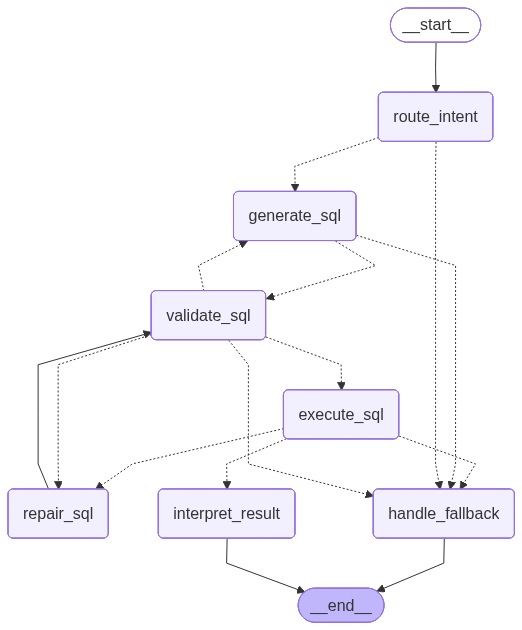

In [4]:
# ── LangGraph flow diagram — rendered from the actual compiled graph ─────────
# draw_mermaid_png() calls mermaid.ink API to produce a PNG — no script tags,
# no CDN issues, works in any Jupyter environment.
from core.graph import nl2sql_app
from IPython.display import display, Image

try:
    png = nl2sql_app.get_graph().draw_mermaid_png()
    display(Image(png))
except Exception as e:
    # Offline fallback: print raw Mermaid syntax
    print('PNG render failed (needs internet for mermaid.ink):', e)
    print()
    print(nl2sql_app.get_graph().draw_mermaid())

---
## Section 14 — Experiment 1: Validation Retry (Case 1)

When the first SQL attempt fails validation (wrong table name, blocked keyword), the pipeline
appends the validation error to the next prompt so the LLM can self-correct.

**What to observe:** `sql_attempts > 1` when the first attempt is invalid.

In [5]:
# ── Simulate validation retry by injecting a bad first SQL ──────────────────
from agents.validator_agent import ValidatorAgent, ValidationResult
from agents.sql_generator import SQLGeneratorAgent
from unittest.mock import patch, MagicMock

validator = ValidatorAgent()
generator = SQLGeneratorAgent()

# Simulate: first generate() returns SQL with a bad table name
bad_sql = 'SELECT * FROM ghost_patients LIMIT 10'  # ghost_patients does not exist
good_sql = 'SELECT * FROM patients LIMIT 10'

call_count = 0
original_generate = generator.generate

def patched_generate(query, validation_error=None):
    global call_count
    call_count += 1
    if call_count == 1:
        print(f'[Attempt 1] Returning bad SQL (no validation_error context)')
        return bad_sql, 100.0, False
    else:
        print(f'[Attempt {call_count}] validation_error passed: {repr(validation_error[:60])}')
        print(f'[Attempt {call_count}] Returning corrected SQL')
        return good_sql, 120.0, False

# Step 1: Validate the bad SQL
sql1, _, _ = patched_generate('Which patients are there?')
result1 = validator.validate(sql1)
print(f'Validation 1: valid={result1.valid}, error={result1.technical_error}')

# Step 2: Pass the error back on retry
sql2, _, _ = patched_generate('Which patients are there?', validation_error=result1.technical_error)
result2 = validator.validate(sql2)
print(f'Validation 2: valid={result2.valid}')

print(f'\nTotal generation calls: {call_count}')
print('=> This is exactly what generate_sql_node does in graph.py')
print('   state["last_validation_error"] is passed to generator.generate() on retry')

2026-04-19 20:59:33 | WARNING  | agents.validator_agent:validate:177 - Validator [schema] FAIL — Unknown tables: ['ghost_patients']
2026-04-19 20:59:33 | INFO     | agents.validator_agent:validate:180 - Validator: all 3 layers passed ✅


[Attempt 1] Returning bad SQL (no validation_error context)
Validation 1: valid=False, error=Unknown tables: ['ghost_patients']
[Attempt 2] validation_error passed: "Unknown tables: ['ghost_patients']"
[Attempt 2] Returning corrected SQL
Validation 2: valid=True

Total generation calls: 2
=> This is exactly what generate_sql_node does in graph.py
   state["last_validation_error"] is passed to generator.generate() on retry


---
## Section 15 — Experiment 2: Backup Model on API Failure (Case 2)

If the primary model (GPT-4o) raises an exception, `invoke_with_backup()` in `BaseAgent`
transparently switches to the backup model (GPT-4o-mini) — a **different** model.

**Why a different model?** `.with_retry()` retries the same model. If the model is
rate-limited or overloaded, every retry hits the same wall. The backup is a different
model ID that routes to a different provider — it's a true fallback, not just a retry.

In [6]:
# ── Demonstrate invoke_with_backup() ─────────────────────────────────────────
from agents.base_agent import BaseAgent
from config import params
from unittest.mock import MagicMock

print('Primary model :', params.model.name)
print('Backup model  :', params.model.backup_name)
print('=> These are DIFFERENT models — the backup is not a retry of the same endpoint')
print()

# Simulate: primary chain raises, backup chain succeeds
class DemoAgent(BaseAgent):
    pass

agent = DemoAgent()

primary_chain = MagicMock()
primary_chain.invoke.side_effect = Exception('503 Service Unavailable (rate limited)')

backup_chain = MagicMock()
backup_chain.invoke.return_value = 'SELECT COUNT(*) FROM patients'

result, used_backup = agent.invoke_with_backup(primary_chain, backup_chain, {'query': 'test'})

print(f'Result       : {result}')
print(f'Used backup  : {used_backup}')
print()
print('In the real pipeline, backup_model_used=True is recorded in state')
print('and surfaced in the Streamlit success banner: "(backup model used)"')

Primary model : openai/gpt-4o
Backup model  : openai/gpt-4o-mini
=> These are DIFFERENT models — the backup is not a retry of the same endpoint



2026-04-19 21:00:46 | INFO     | core.tracer:_get_lf_client:118 - LangFuse v4 client ready (LLM calls will be auto-traced via CallbackHandler)
2026-04-19 21:00:46 | WARNING  | agents.base_agent:invoke_with_backup:140 - DemoAgent primary model failed (openai/gpt-4o): Exception('503 Service Unavailable (rate limited)') — switching to backup (openai/gpt-4o-mini)
2026-04-19 21:00:46 | INFO     | agents.base_agent:invoke_with_backup:147 - DemoAgent backup model succeeded (openai/gpt-4o-mini)


Result       : SELECT COUNT(*) FROM patients
Used backup  : True

In the real pipeline, backup_model_used=True is recorded in state
and surfaced in the Streamlit success banner: "(backup model used)"


---
## Section 16 — Experiment 3: Repairable vs Non-Repairable Execution Errors (Case 3)

The key insight: **not all execution failures are worth repairing with an LLM call**.

- `ambiguous column name` → qualify with table alias → worth one repair attempt
- `no such table` → the SQL references a table that doesn't exist → needs full regen, not a patch

`_is_repairable_error()` in `core/graph.py` makes this decision before routing.

In [7]:
# ── Test _is_repairable_error() classification ───────────────────────────────
from core.graph import _is_repairable_error

test_errors = [
    ('ambiguous column name: patient_id',                    True),
    ('no such column: patients.wrong_col',                   True),
    ('datatype mismatch: expected integer, got text',        True),
    ('aggregate functions not allowed in where clause',      True),
    ('misuse of aggregate function COUNT()',                 True),
    ('no such table: ghost_patients',                        False),
    ('table patients already exists',                        False),
    ('database is locked',                                   False),
    ('attempt to write a readonly database',                 False),
]

print(f'{"Error":<55} {"Repairable?":<12} {"Correct?"}')
print('-' * 85)
all_correct = True
for error, expected in test_errors:
    result = _is_repairable_error(error)
    correct = result == expected
    all_correct = all_correct and correct
    icon = 'OK' if correct else 'WRONG'
    route = 'repair_sql' if result else 'handle_fallback'
    print(f'{error[:54]:<55} {route:<30} [{icon}]')

print()
print('All correct:', all_correct)

Error                                                   Repairable?  Correct?
-------------------------------------------------------------------------------------
ambiguous column name: patient_id                       repair_sql                     [OK]
no such column: patients.wrong_col                      repair_sql                     [OK]
datatype mismatch: expected integer, got text           repair_sql                     [OK]
aggregate functions not allowed in where clause         repair_sql                     [OK]
misuse of aggregate function COUNT()                    repair_sql                     [OK]
no such table: ghost_patients                           handle_fallback                [OK]
table patients already exists                           handle_fallback                [OK]
database is locked                                      handle_fallback                [OK]
attempt to write a readonly database                    handle_fallback                [OK]

All cor

In [8]:
# ── Routing decision table: what happens at execute_sql ──────────────────────
print('execute_sql failure routing logic:')
print()

scenarios = [
    ('ambiguous column name: patient_id',   'repair_sql — surgeon fix with exact error context'),
    ('no such column: bi.dept_id',           'repair_sql — column name typo fixable by repair prompt'),
    ('no such table: ghost_patients',        'handle_fallback — table missing, full regen needed'),
    ('database is locked',                   'handle_fallback — infrastructure error, no LLM can fix'),
]

for error, explanation in scenarios:
    route = 'repair_sql' if _is_repairable_error(error) else 'handle_fallback'
    print(f'Error   : {error}')
    print(f'Route   : {route}')
    print(f'Why     : {explanation}')
    print()

execute_sql failure routing logic:

Error   : ambiguous column name: patient_id
Route   : repair_sql
Why     : repair_sql — surgeon fix with exact error context

Error   : no such column: bi.dept_id
Route   : repair_sql
Why     : repair_sql — column name typo fixable by repair prompt

Error   : no such table: ghost_patients
Route   : handle_fallback
Why     : handle_fallback — table missing, full regen needed

Error   : database is locked
Route   : handle_fallback
Why     : handle_fallback — infrastructure error, no LLM can fix



---
## Launch the Streamlit Dashboard

Run this in your terminal (not in the notebook):

```bash
streamlit run dashboard/app.py
```

The dashboard opens at `http://localhost:8501` with two pages:
1. **NL2SQL Query** — type any question
2. **Pre-Built Dashboard** — 5 live panels